<a href="https://colab.research.google.com/github/nitishrp17/MACHINE-LEARNING-ITA0616-LAB-EXPERIMENTS/blob/main/ML%20EXP%203.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Training Dataset:
     Outlook Temperature Humidity    Wind Play
0      Sunny         Hot     High    Weak   No
1      Sunny         Hot     High  Strong   No
2   Overcast         Hot     High    Weak  Yes
3       Rain        Mild     High    Weak  Yes
4       Rain        Cool   Normal    Weak  Yes
5       Rain        Cool   Normal  Strong   No
6   Overcast        Cool   Normal  Strong  Yes
7      Sunny        Mild     High    Weak   No
8      Sunny        Cool   Normal    Weak  Yes
9       Rain        Mild   Normal    Weak  Yes
10     Sunny        Mild   Normal  Strong  Yes
11  Overcast        Mild     High  Strong  Yes
12  Overcast         Hot   Normal    Weak  Yes
13      Rain        Mild     High  Strong   No


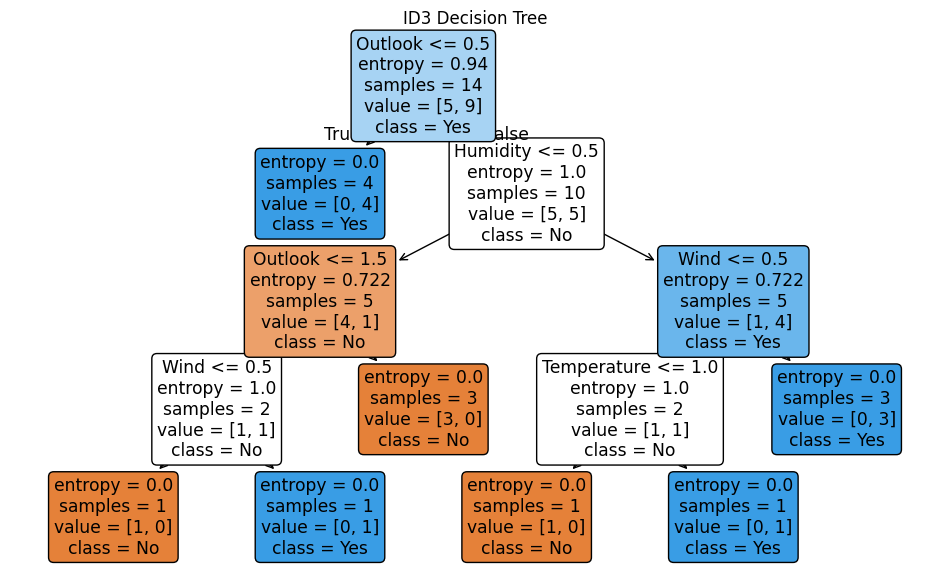


New Sample: Sunny, Cool, Normal, Weak
Classification: Yes


In [4]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

data = pd.DataFrame({
    'Outlook': ['Sunny', 'Sunny', 'Overcast', 'Rain', 'Rain', 'Rain',
                'Overcast', 'Sunny', 'Sunny', 'Rain', 'Sunny',
                'Overcast', 'Overcast', 'Rain'],
    'Temperature': ['Hot', 'Hot', 'Hot', 'Mild', 'Cool', 'Cool',
                    'Cool', 'Mild', 'Cool', 'Mild', 'Mild',
                    'Mild', 'Hot', 'Mild'],
    'Humidity': ['High', 'High', 'High', 'High', 'Normal', 'Normal',
                 'Normal', 'High', 'Normal', 'Normal', 'Normal',
                 'High', 'Normal', 'High'],
    'Wind': ['Weak', 'Strong', 'Weak', 'Weak', 'Weak', 'Strong',
             'Strong', 'Weak', 'Weak', 'Weak', 'Strong',
             'Strong', 'Weak', 'Strong'],
    'Play': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No',
             'Yes', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No']
})

print("Training Dataset:")
print(data)

encoders = {}
for col in data.columns:
    encoders[col] = LabelEncoder()
    data[col] = encoders[col].fit_transform(data[col])

X = data.drop('Play', axis=1)
y = data['Play']

model = DecisionTreeClassifier(criterion='entropy', random_state=0)
model.fit(X, y)

plt.figure(figsize=(12, 7))
plot_tree(model, feature_names=X.columns,
          class_names=encoders['Play'].classes_,
          filled=True, rounded=True)
plt.title("ID3 Decision Tree")
plt.show()

sample = pd.DataFrame([{
    'Outlook': 'Sunny',
    'Temperature': 'Cool',
    'Humidity': 'Normal',
    'Wind': 'Weak'
}])

for col in sample.columns:
    sample[col] = encoders[col].transform(sample[col])

prediction = model.predict(sample)

print("\nNew Sample: Sunny, Cool, Normal, Weak")
print("Classification:", encoders['Play'].inverse_transform(prediction)[0])